## Week 6 – Feature Engineering & Market Metrics

In this section, key housing market metrics are created from the cleaned dataset to better capture pricing behavior, transaction timelines, and regional differences in the real estate market.

In [1]:
# load dataset

import pandas as pd

sold = pd.read_csv("../output/sold_cleaned.csv")

print(sold.shape)
sold.head()

/var/folders/j3/fcm5lwl97232mcc0j6k8vwnr0000gn/T/ipykernel_15993/715153004.py:5: DtypeWarning: Columns (0,1,4,9,64,78,79,80,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv("../output/sold_cleaned.csv")


(397123, 90)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,missing_coord_flag,zero_coord_flag,invalid_longitude_flag
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,NaN,NaN,NaN,NaN,False,False,False,True,False,False
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,...,NaN,NaN,NaN,NaN,False,False,False,True,False,False
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,...,NaN,NaN,NaN,NaN,False,False,False,True,False,False
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1079166779,davidmartz@compass.com,...,NaN,NaN,NaN,NaN,False,True,False,True,False,False
4,Southland,Southland,NaN,False,NaN,NaN,False,1890500.0,1075037759,karen.klein@theagencyre.com,...,NaN,NaN,NaN,NaN,False,False,False,False,False,False


### Convert Date Fields

Ensure all date columns are in datetime format for accurate time-based calculations.

In [14]:
date_cols = ['CloseDate', 'ListingContractDate', 'PurchaseContractDate']

for col in date_cols:
    if col in sold.columns:
        sold[col] = pd.to_datetime(sold[col], errors='coerce')

### Price-Based Metrics

Create normalized pricing indicators to better compare properties of different sizes and listing strategies.

In [15]:
sold['price_per_sqft'] = sold['ClosePrice'] / sold['LivingArea']
sold['price_ratio'] = sold['ClosePrice'] / sold['OriginalListPrice']
sold['sale_to_list_ratio'] = sold['ClosePrice'] / sold['ListPrice']

### Time-Based Features

Extract time components from transaction dates to support trend analysis.

In [16]:
sold['year'] = sold['CloseDate'].dt.year
sold['month'] = sold['CloseDate'].dt.month
sold['year_month'] = sold['CloseDate'].dt.to_period('M')

### Transaction Timeline Metrics

Measure how long properties take to move through each stage of the sales process.

In [17]:
sold['listing_to_contract_days'] = (
    sold['PurchaseContractDate'] - sold['ListingContractDate']
).dt.days

sold['contract_to_close_days'] = (
    sold['CloseDate'] - sold['PurchaseContractDate']
).dt.days

### Feature Validation

Review summary statistics to ensure new features are reasonable and free of major errors.

In [6]:
sold[['price_per_sqft',
      'price_ratio',
      'listing_to_contract_days',
      'contract_to_close_days']].describe()

/Users/yukizhou/miniforge3/envs/dsc80/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,price_per_sqft,price_ratio,listing_to_contract_days,contract_to_close_days
count,3.971230e+05,3.964020e+05,396928.000000,396929.000000
mean,6.455035e+02,inf,45.061817,31.677129
std,5.085216e+03,NaN,87.320363,63.488096
min,4.981497e-04,9.207366e-07,-36407.000000,-331.000000
25%,3.683962e+02,9.535044e-01,10.000000,21.000000
50%,5.373303e+02,9.956522e-01,25.000000,29.000000
75%,7.322654e+02,1.019608e+00,58.000000,36.000000
max,1.164067e+06,inf,14657.000000,36629.000000


### County-Level Market Analysis

Compare pricing and market speed across different counties to identify regional patterns.

In [18]:
county_summary = sold.groupby('CountyOrParish')[
    ['ClosePrice', 'price_per_sqft', 'DaysOnMarket']
].median().sort_values(by='ClosePrice', ascending=False)

county_summary.head(10)

,ClosePrice,price_per_sqft,DaysOnMarket
CountyOrParish,,,
Del Norte,2485000.0,390.907661,320.0
San Mateo,1700000.0,1050.088548,12.0
Santa Clara,1600000.0,967.462160,9.0
Santa Cruz,1200000.0,735.365505,18.0
San Francisco,1180000.0,881.410256,17.0
Orange,1175000.0,671.958697,14.0
Marin,1170000.0,674.546222,22.0
Alameda,1135000.0,701.051577,14.0
Alpine,1100000.0,267.119961,231.0


### Property Type Comparison

Analyze how pricing and market speed differ across property categories.

In [19]:
property_summary = sold.groupby('PropertyType')[
    ['ClosePrice', 'DaysOnMarket']
].median()

property_summary

,ClosePrice,DaysOnMarket
PropertyType,,
Residential,820000.0,19.0


### Market Behavior Insights

Evaluate pricing competitiveness and market speed using key indicators.

In [20]:
sold['sale_to_list_ratio'].describe()
sold['DaysOnMarket'].median()

np.float64(19.0)

### Relationship Between Size and Price

Visualize how property size influences pricing.

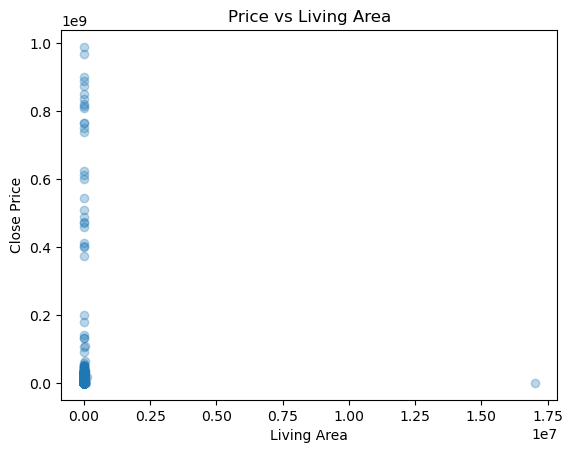

In [12]:
import matplotlib.pyplot as plt

plt.scatter(sold['LivingArea'], sold['ClosePrice'], alpha=0.3)
plt.xlabel("Living Area")
plt.ylabel("Close Price")
plt.title("Price vs Living Area")
plt.show()

### Distribution of Home Prices

Understand the spread and concentration of housing prices.

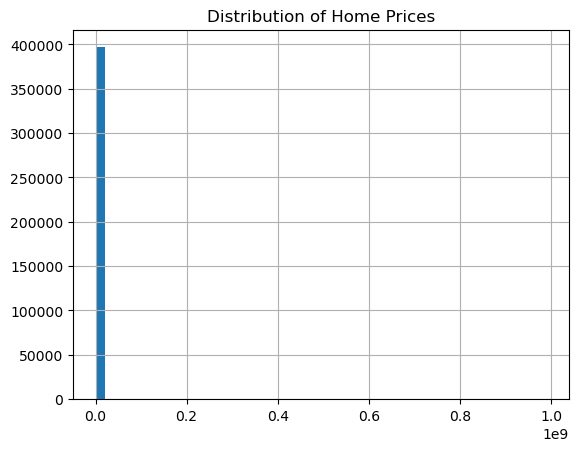

In [13]:
sold['ClosePrice'].hist(bins=50)
plt.title("Distribution of Home Prices")
plt.show()

### Save Engineered Dataset

Export dataset with new features for downstream analysis and dashboard development.

In [21]:
sold.to_csv("../output/sold_features.csv", index=False)
print("Dataset saved successfully")

Dataset saved successfully


## Week 6 – Summary

- Engineered key housing metrics including price per square foot and price ratios to better capture property value  
- Created time-based features to support trend analysis and understand market changes over time  
- Measured transaction timelines to evaluate how quickly properties move through the sales process  
- Identified regional differences in pricing and market activity through county-level segmentation  
- Observed that property value is strongly influenced by living area and location, while market speed varies across regions  
- Prepared a structured dataset ready for dashboard development and further analysis  